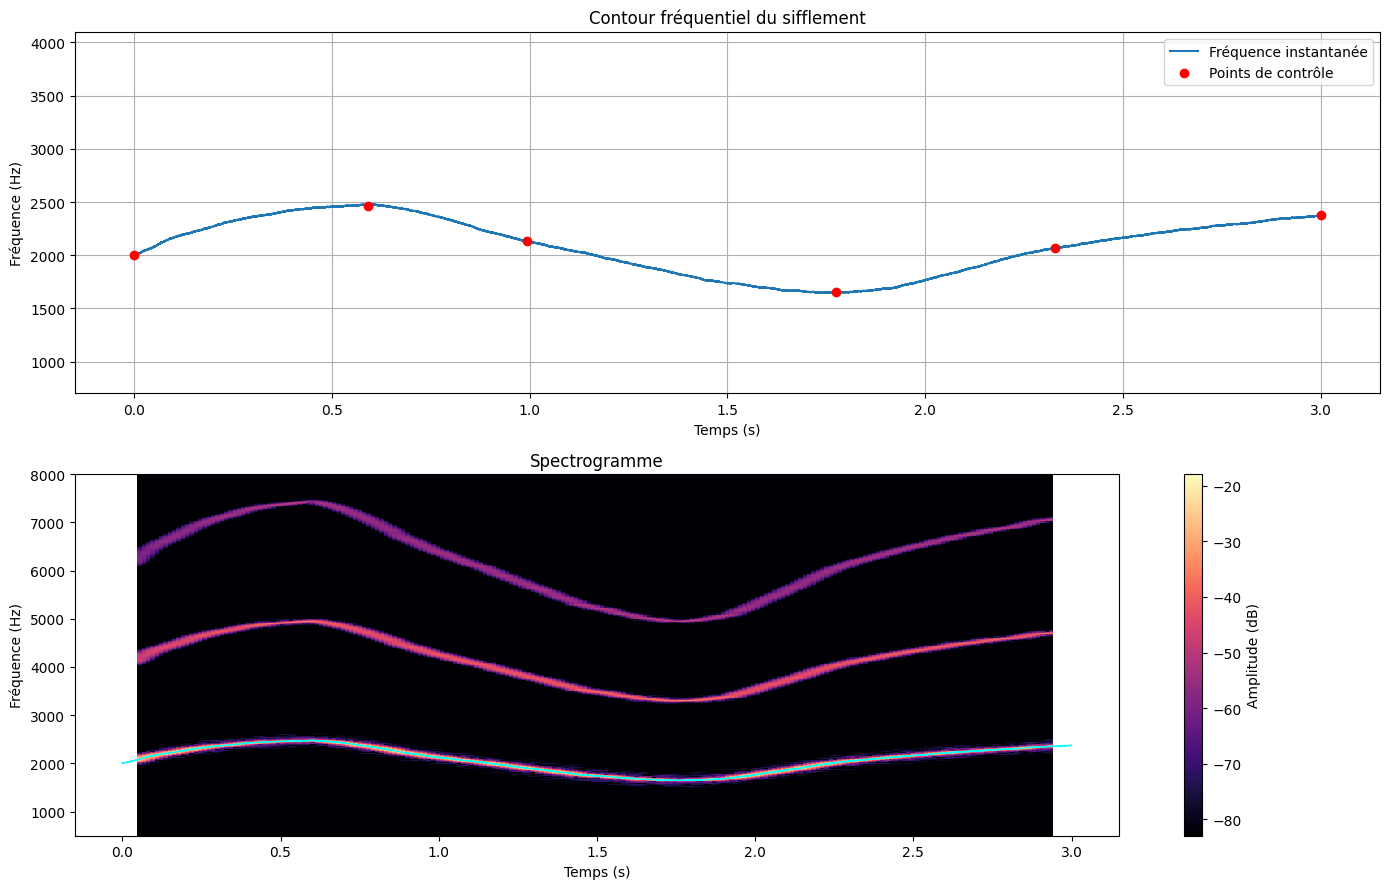

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator
from scipy.signal import lfilter, spectrogram

# --------------------------------------------------
# Paramètres
# --------------------------------------------------
fs = 300_000
duration = 3.0

f_start = 2_000
f_min = 800
f_max = 4_000

rng = np.random.default_rng(seed=42)
t = np.arange(int(fs * duration)) / fs

# --------------------------------------------------
# Contour fréquentiel avec peu d'inflexions
# --------------------------------------------------
control_times = [0.0]
control_freqs = [f_start]

# Direction initiale : montée ou descente
direction = rng.choice([-1, 1])

while control_times[-1] < duration:

    # Chaque mouvement dure entre 0.35 et 0.9 seconde
    segment_duration = rng.uniform(0.35, 0.9)
    next_time = min(control_times[-1] + segment_duration, duration)

    actual_duration = next_time - control_times[-1]

    # 80 % de probabilité de continuer dans la même direction
    if rng.random() > 0.80:
        direction *= -1

    # Vitesse de variation fréquentielle en Hz/s
    sweep_rate = rng.uniform(300, 1_000)

    next_frequency = (
        control_freqs[-1]
        + direction * sweep_rate * actual_duration
    )

    # On change uniquement de direction si une limite est atteinte
    if next_frequency > f_max:
        next_frequency = f_max
        direction = -1

    elif next_frequency < f_min:
        next_frequency = f_min
        direction = 1

    control_times.append(next_time)
    control_freqs.append(next_frequency)

control_times = np.asarray(control_times)
control_freqs = np.asarray(control_freqs)

# Interpolation continue sans oscillations artificielles
contour = PchipInterpolator(control_times, control_freqs)
frequence_principale = contour(t)

# --------------------------------------------------
# Très faibles irrégularités naturelles
# --------------------------------------------------
tau = 0.05
jitter_std = 4  # Hz seulement

a = np.exp(-1 / (fs * tau))

jitter = lfilter(
    [jitter_std * np.sqrt(1 - a**2)],
    [1, -a],
    rng.normal(size=len(t))
)

frequence = np.clip(
    frequence_principale + jitter,
    f_min,
    f_max
)

# --------------------------------------------------
# Génération du signal
# --------------------------------------------------
phase = 2 * np.pi * np.cumsum(frequence) / fs

# Fondamentale dominante avec quelques harmoniques
signal = (
    np.sin(phase)
    + 0.14 * np.sin(2 * phase + 0.2)
    + 0.04 * np.sin(3 * phase)
)

# Enveloppe d'amplitude lente
envelope = 0.75 + 0.15 * np.sin(
    np.pi * t / duration
)

signal *= envelope
signal /= np.max(np.abs(signal))

# Fondu d'entrée et de sortie
fade_duration = 0.04
n_fade = int(fade_duration * fs)
fade = np.sin(np.linspace(0, np.pi / 2, n_fade)) ** 2

signal[:n_fade] *= fade
signal[-n_fade:] *= fade[::-1]

# --------------------------------------------------
# Spectrogramme
# --------------------------------------------------
f_spec, t_spec, S = spectrogram(
    signal,
    fs=fs,
    window="hann",
    nperseg=32768,
    noverlap=28672,
    mode="magnitude"
)

S_db = 20 * np.log10(S + 1e-12)

# --------------------------------------------------
# Affichage
# --------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

axes[0].plot(t, frequence, label="Fréquence instantanée")
axes[0].scatter(
    control_times,
    control_freqs,
    color="red",
    zorder=3,
    label="Points de contrôle"
)
axes[0].set_ylim(f_min - 100, f_max + 100)
axes[0].set_xlabel("Temps (s)")
axes[0].set_ylabel("Fréquence (Hz)")
axes[0].set_title("Contour fréquentiel du sifflement")
axes[0].grid()
axes[0].legend()

image = axes[1].pcolormesh(
    t_spec,
    f_spec,
    S_db,
    shading="auto",
    cmap="magma",
    vmin=S_db.max() - 65,
    vmax=S_db.max()
)

axes[1].plot(
    t,
    frequence,
    color="cyan",
    linewidth=1
)

axes[1].set_ylim(500, 8_000)
axes[1].set_xlabel("Temps (s)")
axes[1].set_ylabel("Fréquence (Hz)")
axes[1].set_title("Spectrogramme")

fig.colorbar(image, ax=axes[1], label="Amplitude (dB)")
plt.tight_layout()
plt.show()

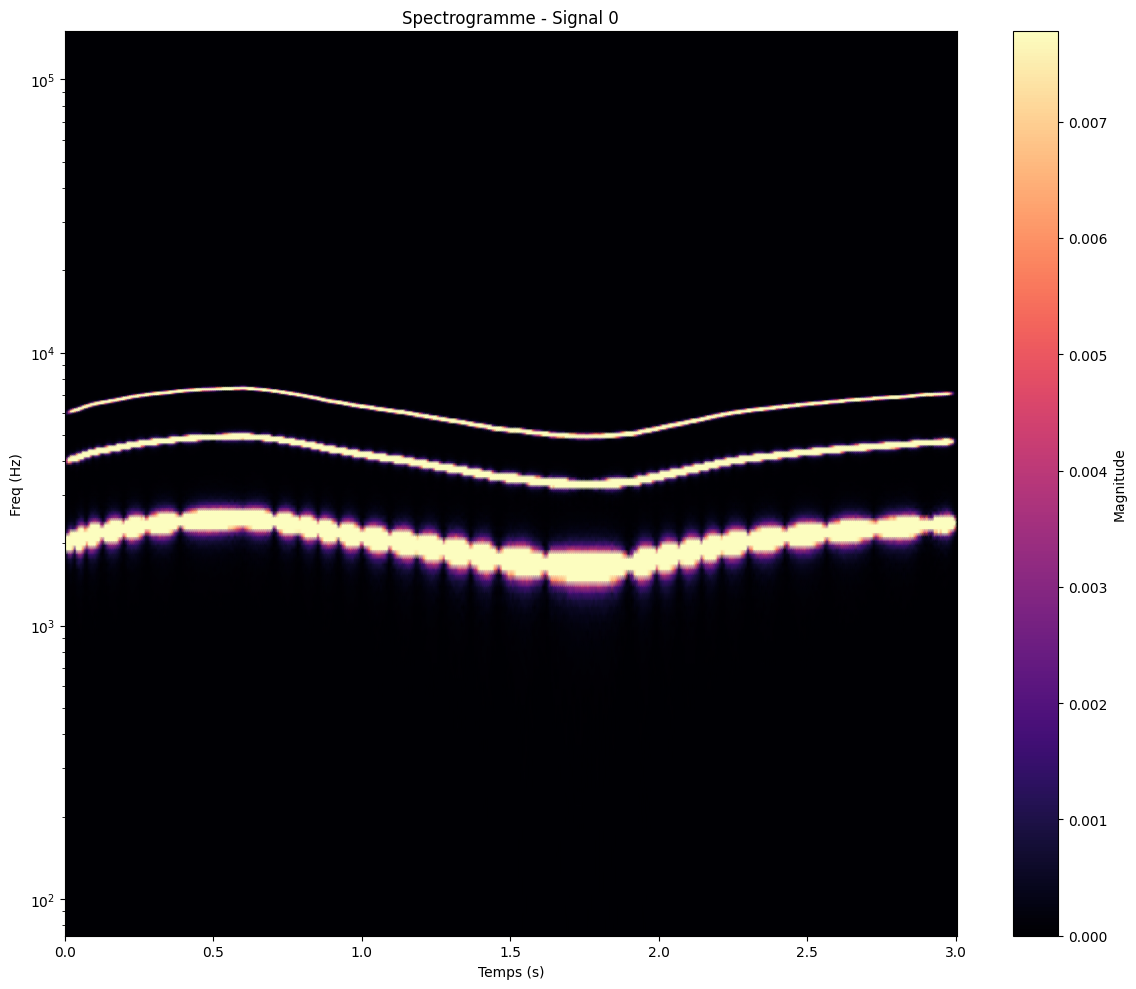

In [12]:
from Beluga.BSS.Utils.signal_class import Signal 
sig = Signal(signal, freq = fs)
fig, axe = sig.plot_spectrogram(nperseg=4096, noverlap=2048, frequency_scale='log')
plt.show()

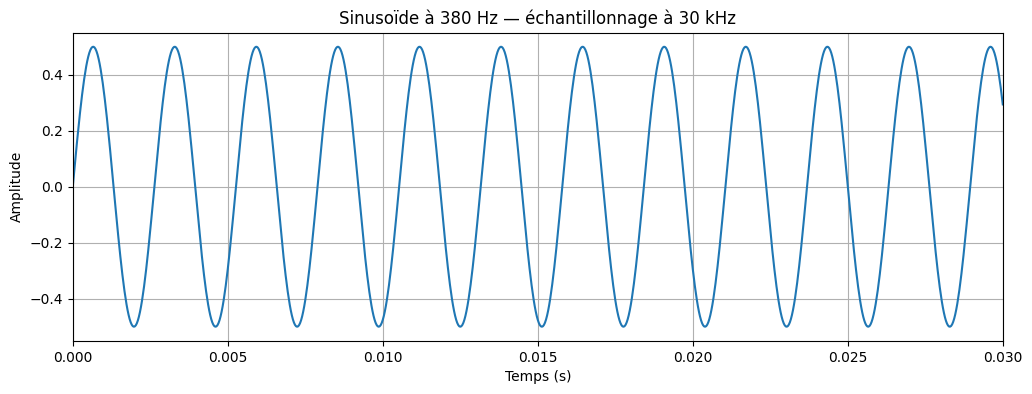

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, displaimport numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter, spectrogram

# Paramètres généraux
fs = 300_000          # fréquence d'échantillonnage (Hz)
duration = 3          # durée du signal (s)
f0 = 2_000            # fréquence centrale (Hz)

# Paramètres des variations aléatoires
tau = 0.25            # durée caractéristique des variations (s)
sigma_f = 150         # écart-type des variations de fréquence (Hz)

dt = 1 / fs
t = np.arange(0, duration, dt)
rng = np.random.default_rng(seed=42)

# Processus aléatoire lent d'Ornstein-Uhlenbeck
a = np.exp(-dt / tau)
bruit = rng.normal(size=len(t))

delta_f = lfilter(
    [sigma_f * np.sqrt(1 - a**2)],
    [1, -a],
    bruit
)

# Fréquence instantanée
frequence = f0 + delta_f

# Intégration de la fréquence pour obtenir la phase
phase = 2 * np.pi * np.cumsum(frequence) / fs

# Signal sinusoïdal
signal = np.sin(phase)

# Calcul du spectrogramme
freq_spectro, temps_spectro, puissance = spectrogram(
    signal,
    fs=fs,
    window="hann",
    nperseg=16_384,
    noverlap=14_336,
    nfft=16_384,
    mode="magnitude"
)

# Conversion en décibels
puissance_db = 20 * np.log10(puissance + 1e-12)

# Affichage
fig, axes = plt.subplots(3, 1, figsize=(13, 10))

# Fréquence instantanée
axes[0].plot(t, frequence, linewidth=0.8)
axes[0].axhline(
    f0,
    color="black",
    linestyle="--",
    label="Fréquence centrale"
)
axes[0].set_ylabel("Fréquence (Hz)")
axes[0].set_title("Fréquence instantanée aléatoire")
axes[0].grid()
axes[0].legend()

# Signal : affichage limité aux 10 premières millisecondes
axes[1].plot(t * 1000, signal)
axes[1].set_xlim(0, 10)
axes[1].set_xlabel("Temps (ms)")
axes[1].set_ylabel("Amplitude")
axes[1].set_title("Début du signal sinusoïdal")
axes[1].grid()

# Spectrogramme
image = axes[2].pcolormesh(
    temps_spectro,
    freq_spectro,
    puissance_db,
    shading="auto",
    cmap="magma"
)

# Fréquence réelle superposée
axes[2].plot(
    t,
    frequence,
    color="cyan",
    linewidth=0.8,
    label="Fréquence instantanée"
)

axes[2].set_ylim(1_000, 3_000)
axes[2].set_xlabel("Temps (s)")
axes[2].set_ylabel("Fréquence (Hz)")
axes[2].set_title("Spectrogramme")
axes[2].legend()

fig.colorbar(image, ax=axes[2], label="Amplitude (dB)")

plt.tight_layout()
plt.show()import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter, spectrogram

# Paramètres généraux
fs = 300_000          # fréquence d'échantillonnage (Hz)
duration = 3          # durée du signal (s)
f0 = 2_000            # fréquence centrale (Hz)

# Paramètres des variations aléatoires
tau = 0.25            # durée caractéristique des variations (s)
sigma_f = 150         # écart-type des variations de fréquence (Hz)

dt = 1 / fs
t = np.arange(0, duration, dt)
rng = np.random.default_rng(seed=42)

# Processus aléatoire lent d'Ornstein-Uhlenbeck
a = np.exp(-dt / tau)
bruit = rng.normal(size=len(t))

delta_f = lfilter(
    [sigma_f * np.sqrt(1 - a**2)],
    [1, -a],
    bruit
)

# Fréquence instantanée
frequence = f0 + delta_f

# Intégration de la fréquence pour obtenir la phase
phase = 2 * np.pi * np.cumsum(frequence) / fs

# Signal sinusoïdal
signal = np.sin(phase)

# Calcul du spectrogramme
freq_spectro, temps_spectro, puissance = spectrogram(
    signal,
    fs=fs,
    window="hann",
    nperseg=16_384,
    noverlap=14_336,
    nfft=16_384,
    mode="magnitude"
)

# Conversion en décibels
puissance_db = 20 * np.log10(puissance + 1e-12)

# Affichage
fig, axes = plt.subplots(3, 1, figsize=(13, 10))

# Fréquence instantanée
axes[0].plot(t, frequence, linewidth=0.8)
axes[0].axhline(
    f0,
    color="black",
    linestyle="--",
    label="Fréquence centrale"
)
axes[0].set_ylabel("Fréquence (Hz)")
axes[0].set_title("Fréquence instantanée aléatoire")
axes[0].grid()
axes[0].legend()

# Signal : affichage limité aux 10 premières millisecondes
axes[1].plot(t * 1000, signal)
axes[1].set_xlim(0, 10)
axes[1].set_xlabel("Temps (ms)")
axes[1].set_ylabel("Amplitude")
axes[1].set_title("Début du signal sinusoïdal")
axes[1].grid()

# Spectrogramme
image = axes[2].pcolormesh(
    temps_spectro,
    freq_spectro,
    puissance_db,
    shading="auto",
    cmap="magma"
)

# Fréquence réelle superposée
axes[2].plot(
    t,
    frequence,
    color="cyan",
    linewidth=0.8,
    label="Fréquence instantanée"
)

axes[2].set_ylim(1_000, 3_000)
axes[2].set_xlabel("Temps (s)")
axes[2].set_ylabel("Fréquence (Hz)")
axes[2].set_title("Spectrogramme")
axes[2].legend()

fig.colorbar(image, ax=axes[2], label="Amplitude (dB)")

plt.tight_layout()
plt.show()import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter, spectrogram

# Paramètres généraux
fs = 300_000          # fréquence d'échantillonnage (Hz)
duration = 3          # durée du signal (s)
f0 = 2_000            # fréquence centrale (Hz)

# Paramètres des variations aléatoires
tau = 0.25            # durée caractéristique des variations (s)
sigma_f = 150         # écart-type des variations de fréquence (Hz)

dt = 1 / fs
t = np.arange(0, duration, dt)
rng = np.random.default_rng(seed=42)

# Processus aléatoire lent d'Ornstein-Uhlenbeck
a = np.exp(-dt / tau)
bruit = rng.normal(size=len(t))

delta_f = lfilter(
    [sigma_f * np.sqrt(1 - a**2)],
    [1, -a],
    bruit
)

# Fréquence instantanée
frequence = f0 + delta_f

# Intégration de la fréquence pour obtenir la phase
phase = 2 * np.pi * np.cumsum(frequence) / fs

# Signal sinusoïdal
signal = np.sin(phase)

# Calcul du spectrogramme
freq_spectro, temps_spectro, puissance = spectrogram(
    signal,
    fs=fs,
    window="hann",
    nperseg=16_384,
    noverlap=14_336,
    nfft=16_384,
    mode="magnitude"
)

# Conversion en décibels
puissance_db = 20 * np.log10(puissance + 1e-12)

# Affichage
fig, axes = plt.subplots(3, 1, figsize=(13, 10))

# Fréquence instantanée
axes[0].plot(t, frequence, linewidth=0.8)
axes[0].axhline(
    f0,
    color="black",
    linestyle="--",
    label="Fréquence centrale"
)
axes[0].set_ylabel("Fréquence (Hz)")
axes[0].set_title("Fréquence instantanée aléatoire")
axes[0].grid()
axes[0].legend()

# Signal : affichage limité aux 10 premières millisecondes
axes[1].plot(t * 1000, signal)
axes[1].set_xlim(0, 10)
axes[1].set_xlabel("Temps (ms)")
axes[1].set_ylabel("Amplitude")
axes[1].set_title("Début du signal sinusoïdal")
axes[1].grid()

# Spectrogramme
image = axes[2].pcolormesh(
    temps_spectro,
    freq_spectro,
    puissance_db,
    shading="auto",
    cmap="magma"
)

# Fréquence réelle superposée
axes[2].plot(
    t,
    frequence,
    color="cyan",
    linewidth=0.8,
    label="Fréquence instantanée"
)

axes[2].set_ylim(1_000, 3_000)
axes[2].set_xlabel("Temps (s)")
axes[2].set_ylabel("Fréquence (Hz)")
axes[2].set_title("Spectrogramme")
axes[2].legend()

fig.colorbar(image, ax=axes[2], label="Amplitude (dB)")

plt.tight_layout()
plt.show()import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter, spectrogram

# Paramètres généraux
fs = 300_000          # fréquence d'échantillonnage (Hz)
duration = 3          # durée du signal (s)
f0 = 2_000            # fréquence centrale (Hz)

# Paramètres des variations aléatoires
tau = 0.25            # durée caractéristique des variations (s)
sigma_f = 150         # écart-type des variations de fréquence (Hz)

dt = 1 / fs
t = np.arange(0, duration, dt)
rng = np.random.default_rng(seed=42)

# Processus aléatoire lent d'Ornstein-Uhlenbeck
a = np.exp(-dt / tau)
bruit = rng.normal(size=len(t))

delta_f = lfilter(
    [sigma_f * np.sqrt(1 - a**2)],
    [1, -a],
    bruit
)

# Fréquence instantanée
frequence = f0 + delta_f

# Intégration de la fréquence pour obtenir la phase
phase = 2 * np.pi * np.cumsum(frequence) / fs

# Signal sinusoïdal
signal = np.sin(phase)

# Calcul du spectrogramme
freq_spectro, temps_spectro, puissance = spectrogram(
    signal,
    fs=fs,
    window="hann",


C:\Users\BORDERIES\AppData\Local\Temp\ipykernel_25896\3668390260.py:101: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


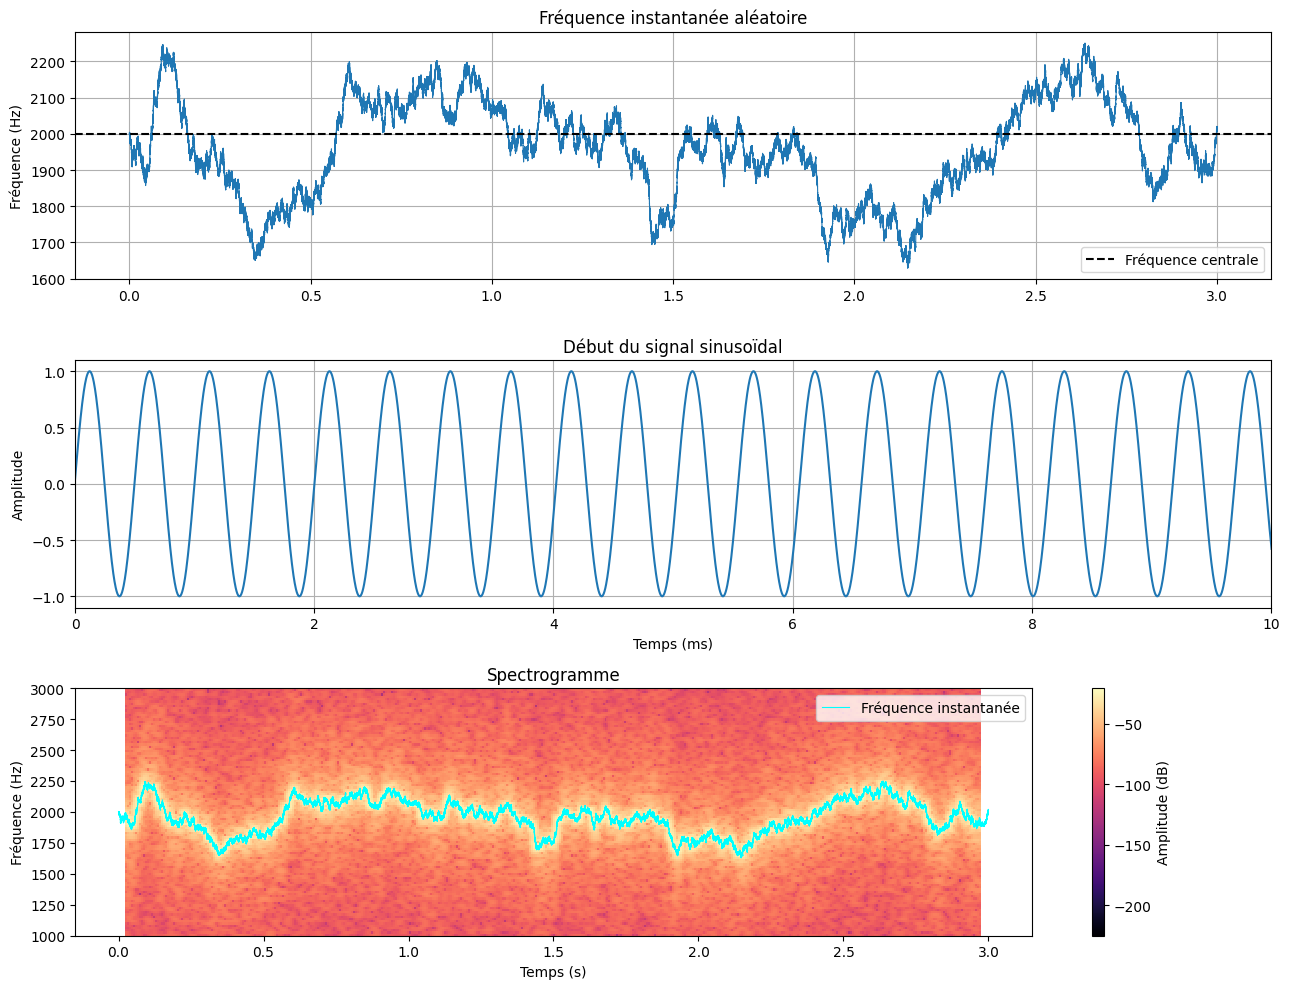

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter, spectrogram

# Paramètres généraux
fs = 300_000          # fréquence d'échantillonnage (Hz)
duration = 3          # durée du signal (s)
f0 = 2_000            # fréquence centrale (Hz)

# Paramètres des variations aléatoires
tau = 0.25            # durée caractéristique des variations (s)
sigma_f = 150         # écart-type des variations de fréquence (Hz)

dt = 1 / fs
t = np.arange(0, duration, dt)
rng = np.random.default_rng(seed=42)

# Processus aléatoire lent d'Ornstein-Uhlenbeck
a = np.exp(-dt / tau)
bruit = rng.normal(size=len(t))

delta_f = lfilter(
    [sigma_f * np.sqrt(1 - a**2)],
    [1, -a],
    bruit
)

# Fréquence instantanée
frequence = f0 + delta_f

# Intégration de la fréquence pour obtenir la phase
phase = 2 * np.pi * np.cumsum(frequence) / fs

# Signal sinusoïdal
signal = np.sin(phase)

# Calcul du spectrogramme
freq_spectro, temps_spectro, puissance = spectrogram(
    signal,
    fs=fs,
    window="hann",
    nperseg=16_384,
    noverlap=14_336,
    nfft=16_384,
    mode="magnitude"
)

# Conversion en décibels
puissance_db = 20 * np.log10(puissance + 1e-12)

# Affichage
fig, axes = plt.subplots(3, 1, figsize=(13, 10))

# Fréquence instantanée
axes[0].plot(t, frequence, linewidth=0.8)
axes[0].axhline(
    f0,
    color="black",
    linestyle="--",
    label="Fréquence centrale"
)
axes[0].set_ylabel("Fréquence (Hz)")
axes[0].set_title("Fréquence instantanée aléatoire")
axes[0].grid()
axes[0].legend()

# Signal : affichage limité aux 10 premières millisecondes
axes[1].plot(t * 1000, signal)
axes[1].set_xlim(0, 10)
axes[1].set_xlabel("Temps (ms)")
axes[1].set_ylabel("Amplitude")
axes[1].set_title("Début du signal sinusoïdal")
axes[1].grid()

# Spectrogramme
image = axes[2].pcolormesh(
    temps_spectro,
    freq_spectro,
    puissance_db,
    shading="auto",
    cmap="magma"
)

# Fréquence réelle superposée
axes[2].plot(
    t,
    frequence,
    color="cyan",
    linewidth=0.8,
    label="Fréquence instantanée"
)

axes[2].set_ylim(1_000, 3_000)
axes[2].set_xlabel("Temps (s)")
axes[2].set_ylabel("Fréquence (Hz)")
axes[2].set_title("Spectrogramme")
axes[2].legend()

fig.colorbar(image, ax=axes[2], label="Amplitude (dB)")

plt.tight_layout()
plt.show()